In [1]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
import math
import sys
from numpy.polynomial import Chebyshev, Polynomial
from scipy.ndimage import label
import numpy.polynomial.polynomial as poly
from PIL import Image
import warnings
np.set_printoptions(threshold=sys.maxsize)

In [2]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images

In [3]:
pics = np.zeros(shape=(7, 256, 256, 3))
pics = load_images_from_folder('C:\\Users\\2020\\Documents\\3 Academics\\Cambridge\\Publications\\Computer Vision\\Figures and Original Soln\\pics')

In [4]:
img1 = pics[-2].astype('uint8')
img1[2][2] = 50; img1[2][6] = 0; img1[3][2] = 50; img1[3][3] = 50; img1[3][4] = 50; img1[3][5] = 50; img1[4][2] = 50; img1[4][4] = 0
img1[4][5] = 50; img1[4][6] = 50; img1[5][2] = 50; img1[5][3] = 50; img1[5][4] = 50; img1[5][5] = 50; img1[5][6] = 50

img2 = pics[-2].astype('uint8')
img2[2][2] = 50; img2[2][6] = 0; img2[3][2] = 50; img2[3][3] = 50; img2[3][4] = 50; img2[3][5] = 50; img2[4][2] = 50; img2[4][4] = 0
img2[4][5] = 50; img2[4][6] = 50; img2[5][2] = 50; img2[5][3] = 50; img2[5][4] = 50; img2[5][5] = 50; img2[5][6] = 50
img2[0][0] = [255,255,60]; img2[0][1] = [255,255,60]; img2[0][2] = [255,255,60];   img2[0][3] = [255,255,60]; img2[0][4] = [255,255,60]
img2[0][5] = [255,255,60]; img2[0][6] = [255,255,60]; img2[0][7] = [255,255,60]; img2[7][0] = [255,255,60]; img2[7][1] = [255,255,60]
img2[7][2] = [255,255,60]; img2[7][3] = [255,255,60]; img2[7][4] = [255,255,60]; img2[7][5] = [255,255,60]; img2[7][6] = [255,255,60]
img2[7][7] = [255,255,60]; img2[1][0] = [255,255,60]; img2[2][0] = [255,255,60]; img2[3][0] = [255,255,60]; img2[4][0] = [255,255,60]
img2[5][0] = [255,255,60]; img2[6][0] = [255,255,60]; img2[1][7] = [255,255,60]; img2[2][7] = [255,255,60]; img2[3][7] = [255,255,60]
img2[4][7] = [255,255,60]; img2[5][7] = [255,255,60]; img2[6][7] = [255,255,60]; img2[1][1] = [255,255,60]; img2[2][1] = [255,255,60]
img2[3][1] = [255,255,60]; img2[4][1] = [255,255,60]; img2[5][1] = [255,255,60]; img2[6][1] = [255,255,60]; img2[6][2] = [255,255,60]
img2[6][3] = [255,255,60]; img2[6][4] = [255,255,60]; img2[6][5] = [255,255,60]; img2[6][6] = [255,255,60]; img2[6][7] = [255,255,60]
img2[3][6] = [60,255,255]
#f, axarr = plt.subplots(1,2)
#axarr[0].imshow(img1[...,::-1])
#axarr[1].imshow(img2[...,::-1])

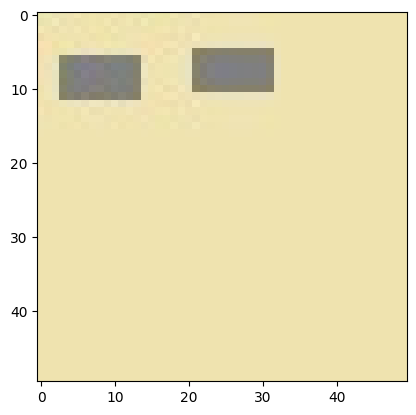

In [ ]:
chosenImage = pics[3]

#HYPERPARAMETERS
thresh = 0.2                # color similarity threshold
percentMerge = 0.2          # minimum cluster size as % of image

# Convert BGR to RGB for PIL (PIL expects RGB format)
chosenImageRGB = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
im = Image.fromarray(chosenImageRGB)
im.save('test.png')
im.save('test.jpg')
im.save('test.tiff')
plt.imshow(cv2.cvtColor(chosenImage, cv2.COLOR_RGB2BGR))
plt.show()

In [6]:
def checkFit(cMean, pixel):
    # Compute current cluster mean
    h_mean = np.mean(cMean[0])
    s_mean = np.mean(cMean[1])
    v_mean = np.mean(cMean[2])
    
    # Circular hue difference (normalized to [0,1])
    dh = min(abs(pixel[0] - h_mean), 180 - abs(pixel[0] - h_mean)) / 180.0
    
    # Saturation and value differences (normalized)
    ds = abs(pixel[1] - s_mean) / 255.0
    dv = abs(pixel[2] - v_mean) / 255.0
    
    # Weighted distance: emphasize hue, de-emphasize value
    return np.sqrt((2 * dh)**2 + ds**2 + (0.5 * dv)**2)

In [7]:
img = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2HSV)

In [ ]:
# Convert input image to HSV
img = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2HSV)

# Remove old compressed file if it exists
if os.path.exists("imComp.txt"):
    os.remove("imComp.txt")

# imgClusters[i,j] = cluster number pixel belongs to
imgClusters = np.ones((img.shape[0], img.shape[1]), dtype=int)

# List of perimeter pixels for each cluster
clusterEdges = []

# visited[i,j] = 1 - pixel not yet assigned to any cluster
# visited[i,j] = 0 - pixel already assigned
visited = np.ones((img.shape[0], img.shape[1]), dtype=int)

clusterNum = 1              # current cluster ID
clustMeans = []             # mean HSV per cluster

# 4-connected neighborhood definition
structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]])

# Continue until all pixels have been assigned
while np.count_nonzero(visited) > 0:

    firstFind = 0            # flag to find seed pixel
    clust = []               # border pixels for this cluster

    # Greedy assumption: all unvisited pixels could be in this cluster
    imgClusters[visited != 0] = clusterNum

    # ---- STEP 1: find the seed pixel and initialize cluster mean ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            if visited[i][j] == 1 and firstFind == 0:
                # First unvisited pixel becomes the seed
                startX, startY = i, j

                # Cluster mean stored as lists
                cMean = [[], [], []]
                cMean[0].append(img[i][j][0])
                cMean[1].append(img[i][j][1])
                cMean[2].append(img[i][j][2])

                firstFind = 1

    # ---- STEP 2: build the similarity mask, replaces recursion ----
    # fitMask[i,j] = True if pixel is unvisited AND fits cluster mean
    fitMask = np.zeros((img.shape[0], img.shape[1]), dtype=bool)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if visited[i][j] == 1:
                if checkFit(cMean, img[i][j]) < thresh:
                    fitMask[i][j] = True

    # ---- STEP 3: connected component labeling (4-connected) ----
    # Each connected region of True pixels gets a unique label
    labels, numLabels = label(fitMask, structure)

    # Label of the connected component containing the seed pixel
    seedLabel = labels[startX, startY]

    # region[i,j] = True ONLY for pixels reachable from the seed
    region = (labels == seedLabel)

    # ---- STEP 4: accept pixels in this connected component ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if region[i][j]:
                visited[i][j] = 0                # mark as assigned
                imgClusters[i][j] = clusterNum   # assign cluster

                # update cluster mean
                cMean[0].append(img[i][j][0])
                cMean[1].append(img[i][j][1])
                cMean[2].append(img[i][j][2])

    # ---- STEP 5: border detection ----
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if region[i][j]:

                # Check 4 neighbors only (same as recursion logic)
                for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
                    ni, nj = i + di, j + dj

                    # Absolute image border - border pixel
                    if ni < 0 or nj < 0 or ni >= img.shape[0] or nj >= img.shape[1]:
                        clust.append((i, j))
                        break

                    # Neighbor not in same component - border pixel
                    if not region[ni][nj]:
                        clust.append((i, j))
                        break

    # ---- STEP 6: finalize this cluster ----
    clusterEdges.append(list(set(clust)))

    clustMeans.append((
        int(np.rint(np.mean(cMean[0]))),
        int(np.rint(np.mean(cMean[1]))),
        int(np.rint(np.mean(cMean[2])))
    ))

    clusterNum += 1


In [ ]:
# Percent merge function
rowsToDelete = []
for i in range(0, len(clusterEdges)):
    if (len(clusterEdges[i])/(img1.shape[0]*img1.shape[1])) < percentMerge:
        for coord in clusterEdges[i]:
            # Find closest point
            closest = 1000
            clustJoin = -1
            for j in range(0,len(clusterEdges)):
                if j == i:
                    continue
                for k in range(0, len(clusterEdges[j])):
                    dist = math.dist(coord, clusterEdges[j][k])
                    if dist < closest:
                        closest = dist
                        clustJoin = j
            # add point's to closest points cluster 
            imgClusters[coord] = clustJoin+1
            
            # determine if new point is border pixel and add if so
            r1 = -1
            r2 = -1
            addPix = False
            for m in range(0,3):
                for n in range(0,3):
                    if (imgClusters[i+r1+m][j+r2+n] != clustJoin):
                        addPix = True
            if addPix:
                clusterEdges[clustJoin].append(coord)
                
            # delete row and its mean
        rowsToDelete.append(i)
rowsToDelete = sorted(rowsToDelete, reverse=True)
for row in rowsToDelete:
    del clusterEdges[row]
    del clustMeans[row]

In [ ]:
# Trace the outer edge of a cluster of pixels.
# Returns ordered X and Y coordinates along the contour.
def traceClusterEdges(cluster):
    if len(cluster) == 0:
        return [], []

    # Convert cluster to set for O(1) membership check
    pixels = set(cluster)

    # clockwise starting from north
    directions = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                  (1, 0), (1, -1), (0, -1), (-1, -1)]

    # Find starting pixel: top-left-most
    start = min(pixels, key=lambda c: (c[1], c[0]))
    x, y = start
    contour = [(x, y)]
    current = start
    prev_dir = 6  # start looking from left neighbor (south-west)

    while True:
        found_next = False
        # Check 8 neighbors clockwise starting from (prev_dir + 1)
        for i in range(8):
            idx = (prev_dir + 1 + i) % 8
            dx, dy = directions[idx]
            neighbor = (current[0] + dx, current[1] + dy)
            if neighbor in pixels:
                contour.append(neighbor)
                current = neighbor
                prev_dir = (idx + 4) % 8  # set new prev_dir opposite direction
                found_next = True
                break
        if not found_next or current == start:
            break

    # Separate X and Y
    X, Y = zip(*contour)
    return list(X), list(Y)

In [11]:
edgesSorted = []
for cluster in clusterEdges:
    xList, yList = traceClusterEdges(cluster)
    edgesSorted.append([xList, yList])

In [ ]:
# New polyFit function using Chebyshev fitting
def polyFitCheby(x, y):
    x = np.array(x)
    y = np.array(y)

    # Sort by x-coordinate for better contour fitting
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    if len(x) <= 1:
        # Return a simple array for consistency
        return np.array([y[0]]) 

    # Try degrees from 0 to 5
    best_coeffs = None
    for deg in range(6):
        c_fit = Chebyshev.fit(x, y, deg)
        
        # Calculate R2 score to check accuracy
        y_pred = c_fit(x)
        
        # Avoid R2 score crash on single-value clusters
        if np.var(y) == 0:
            score = 1.0
        else:
            score = r2_score(y, y_pred)
            
        if score > 0.9 or deg == 5:
            best_coeffs = c_fit.convert().coef
            return best_coeffs[::-1]

In [ ]:
# New polyFit function using Polynomial.fit
def polyFitPolyNew(x, y):
    x = np.array(x)
    y = np.array(y)

    # Standard sorting for coordinate fitting
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    if len(x) <= 1:
        return np.array([y[0]]) 

    for i in range(6):
        p_fit = Polynomial.fit(x, y, i)
        
        y_pred = p_fit(x)
        
        if np.var(y) == 0:
            score = 1.0
        else:
            score = r2_score(y, y_pred)
            
        if score > 0.9 or i == 5:
            return p_fit.convert().coef[::-1]

In [ ]:
# Old Fit to polynomial function
def polyFit(x,y):
    y = np.array(y)
    x = np.array(x)

    # Sort by x-coordinate for better contour fitting
    #print("Pre sort:", x, y)
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]

    #print("In fitting:", x, y)
    if len(x) <= 1:
        return np.array([y[0]])  # trivial fit for single point
    for i in range(0,6):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=np.exceptions.RankWarning)
            pol = np.poly1d(np.polyfit(x, y, i))
        #print("Degree", i)
        test = pol(x).astype(int)
        #print("Res:", r2_score(y, pol(x)))
        if r2_score(y, pol(x)) > 0.9 or i == 5:
            #print("here", r2_score(y, pol(x)), pol.c)
            #print(pol(x), y)
            return pol.c

In [15]:
f = open("imComp.txt", "a")

for i in range(0, len(edgesSorted)):
    # Write cluster color
    f.write("C;" + str(clustMeans[i][0]) + ',' + str(clustMeans[i][1]) + ',' + str(clustMeans[i][2]) + ';\n')

    l = [[], []]
    vert = [[], []]
    track = -1

    if len(edgesSorted[i][0]) < 2:
        continue

    for j in range(0, len(edgesSorted[i]), 2):
        clustSize = len(edgesSorted[i][j])

        # Always take last point as the true end
        saveX = edgesSorted[i][j][-1]
        saveY = edgesSorted[i][j+1][-1]

        for k in range(0, clustSize):
            x = edgesSorted[i][j][k]
            y = edgesSorted[i][j+1][k]
            #print("x, y: ", k)
            #print("vert: ", vert)
            #print("poly points: ", l)

            if x not in l[0]:
                if track == 1 and len(vert[0]) > 0:
                    f.write("V;" + str(vert[0][0]) + ',' + str(vert[1][0]) +
                            ';' + str(vert[0][-1]) + ',' + str(vert[1][-1]) + ';\n')
                    #print("Vertical run fitting!: ", vert[0], vert[1])
                vert = [[], []]
                track = 0
            else:
                if track == 0 and len(l[0]) > 1:
                    #coefs1 = polyFit(l[0], l[1])
                    coefs = polyFitCheby(l[0], l[1])
                    #coefs3 = polyFitPolyNew(l[0], l[1]) 
                    #print("Fit x and y: ", l[0], l[1])
                    #print("Coefs1: ", coefs1, "\nCoefs2: ", coefs2, "\nCoefs3: ", coefs3)
                    #coefs = coefs3
                    #print("Coefs: ", coefs)
                    coefs[np.abs(coefs) < 1e-3] = 0
                    # Find the first non-zero coefficient
                    nonzero_idx = np.argmax(coefs != 0)  # index of first non-zero
                    # Slice to remove leading zeros
                    coefs = coefs[nonzero_idx:]
                    #print("Coefs: ", coefs)
                    poly = ','.join(str(c) for c in coefs)
                    f.write("P;" + str(l[0][0]) + ';' + poly + ';' + str(l[0][-1]) + ';\n')
                l = [[], []]
                track = 1

            vert[0].append(x)
            vert[1].append(y)
            l[0].append(x)
            l[1].append(y)

            if k == clustSize - 1:
                if track == 1 and len(vert[0]) > 0:
                    f.write("V;" + str(vert[0][0]) + ',' + str(vert[1][0]) +
                            ';' + str(vert[0][-1]) + ',' + str(vert[1][-1]) + ';\n')
                    #print("Final Vertical run fitting!: ", vert[0], vert[1])
                elif track == 0 and len(l[0]) > 1:
                    #print("Final Polynomial Fitting!: ", l[0], l[1])
                    coefs = polyFit(l[0], l[1])
                    #print("Coefs: ", coefs)
                    coefs[np.abs(coefs) < 1e-4] = 0
                    # Find the first non-zero coefficient
                    nonzero_idx = np.argmax(coefs != 0)  # index of first non-zero
                    # Slice to remove leading zeros
                    coefs = coefs[nonzero_idx:]
                    #print("Coefs: ", coefs)
                    poly = ','.join(str(c) for c in coefs)
                    f.write("P;" + str(l[0][0]) + ';' + poly + ';' + str(l[0][-1]) + ';\n')

        f.write(".\n")

    # Write final endpoint
    f.write("E;" + str(saveX) + ',' + str(saveY) + ';\n\n')

f.close()


In [16]:
#Compare final compression to jpg and png
print("Fish compress:", os.path.getsize('imComp.txt'))
print("JPEG compress:", os.path.getsize('test.jpg'))
print("PNG compress:", os.path.getsize('test.png'))
print("Tiff compress:", os.path.getsize('test.tiff'))

Fish compress: 801
JPEG compress: 862
PNG compress: 1116
Tiff compress: 7640


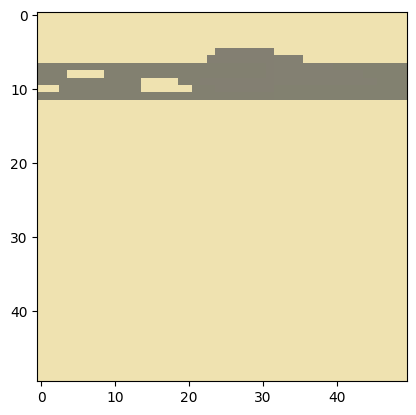

In [ ]:
# 1. Initialize recovery image and a list to track cluster sizes for sorting
imRecover = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
clusters_to_draw = []

# 2. Read the file once to collect all shapes and their data
with open("imComp.txt", "r") as f:
    current_cluster = None
    
    for line in f:
        l = line.strip().split(';')
        
        if 'C' in l[0]:
            # New cluster: Start a new dictionary to hold its data
            color = np.array([int(i) for i in l[1].split(',')])
            current_cluster = {'color': color, 'pts': []}
            clusters_to_draw.append(current_cluster)
            
        elif 'P' in l[0] and current_cluster is not None:
            # polynomial logic
            startPt = int(l[1])
            poly_coeffs = [float(i) for i in l[2].split(',')]
            p = np.poly1d(poly_coeffs)
            endPt = int(l[3])
            
            step = 1 if endPt >= startPt else -1
            for r in range(startPt, endPt + step, step):
                c = int(round(p(r)))
                # Using (c, r) for fillPoly which expects (x, y)
                current_cluster['pts'].append([c, r]) 

        elif 'V' in l[0] and current_cluster is not None:
            # vertical line logic
            r_start, c_start = [int(k) for k in l[1].split(',')]
            r_end, c_end = [int(k) for k in l[2].split(',')]
            
            steps = max(abs(r_end - r_start), abs(c_end - c_start))
            if steps > 0:
                for s in range(steps + 1):
                    rr = int(r_start + s * (r_end - r_start) / steps)
                    cc = int(c_start + s * (c_end - c_start) / steps)
                    current_cluster['pts'].append([cc, rr])

# 3. THE PAINTER'S ALGORITHM
# Sort clusters so the largest ones (background) are drawn first
clusters_to_draw.sort(key=lambda x: len(x['pts']), reverse=True)

# 4. DRAWING PHASE
for cluster in clusters_to_draw:
    if len(cluster['pts']) > 2:
        # Convert the points to the exact format OpenCV needs: (N, 1, 2)
        polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(imRecover, [polygon_points], color=cluster['color'].tolist())

# Show the result using your existing display logic
plt.imshow(cv2.cvtColor(imRecover, cv2.COLOR_HSV2RGB))
plt.show()

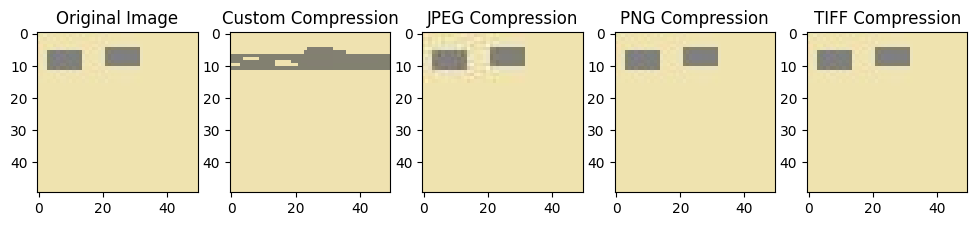

In [18]:
imj = cv2.imread('test.jpg')
imp = cv2.imread('test.png')
imt = cv2.imread('test.tiff')
f, axarr = plt.subplots(1,5, figsize=(12, 6))
axarr[0].imshow(chosenImage[...,::-1])
axarr[0].title.set_text('Original Image')
axarr[1].imshow(cv2.cvtColor(imRecover, cv2.COLOR_HSV2RGB))
axarr[1].title.set_text('Custom Compression')
axarr[2].imshow(imj[...,::-1])  # BGR to RGB for matplotlib
axarr[2].title.set_text('JPEG Compression')
axarr[3].imshow(imp[...,::-1])  # BGR to RGB for matplotlib
axarr[3].title.set_text('PNG Compression')
axarr[4].imshow(imt[...,::-1])  # BGR to RGB for matplotlib
axarr[4].title.set_text('TIFF Compression')